
## Como Ler Este Volume

1. Visao geral do projeto e do recorte metodologico adotado nesta variante.
2. Leitura da base longa canonicamente versionada.
3. Agregacoes analiticas em memoria para descricoes e comparacoes.
4. Dicionario de dados e validacao da base longa.

Esta versao deriva de `PAD_projeto.ipynb`, mas remove deliberadamente a infraestrutura de snapshot. O foco aqui recai sobre a **base longa** como unidade canonica de dados e auditoria.



## 2. Contexto do Estudo

Este projeto foi organizado como um estudo **quantitativo, aplicado, descritivo e exploratorio**. O objetivo desta variante e preservar a leitura substantiva do trabalho sem depender de uma camada sintetica municipal exportada.

A base do trabalho articula populacao municipal, PAM, PPM, Censo Agropecuario e indicadores educacionais rurais. A integracao continua sendo feita por `codigo_municipio` de 7 digitos, e o recorte `Rural` segue explicito no bloco educacional.

Nesta leitura, a **base longa** passa a ser o centro do projeto. As tabelas municipais usadas ao longo do notebook sao geradas apenas em memoria, sob demanda analitica, sem se converterem em novo artefato canonico.



## 3. Base Longa e Agregacoes Analiticas

A seguir esta o nucleo operacional da variante snapshot-free: leitura da base longa, organizacao das principais tabelas de apoio e producao de agregacoes temporarias para comparacoes descritivas. Nenhum snapshot municipal e lido, escrito ou validado neste volume.


In [1]:

from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

SUBDOMINIOS_CENTRAIS = {
    "populacao_municipal",
    "pam_area_colhida",
    "ppm_rebanhos",
    "censo_agro_estrutura",
    "censo_agro_mecanizacao",
    "matriculas_ensino_medio",
    "rendimento_escolar",
}
PAM_PRODUTOS = {
    "Algodao herbaceo (em caroco)": "area_algodao_hectares_2024",
    "Cana-de-acucar": "area_cana_hectares_2024",
    "Milho (em grao)": "area_milho_hectares_2024",
    "Soja (em grao)": "area_soja_hectares_2024",
}
METRICAS_ANALITICAS = [
    "populacao_total_2024",
    "variacao_populacao_2010_2024_pct",
    "area_total_culturas_selecionadas_hectares_2024",
    "efetivo_bovino_2024",
    "num_tratores_2017",
    "matriculas_ensino_medio_rural_2024",
    "taxa_abandono_rural_2024",
]


@dataclass
class PipelineArtifacts:
    configuracao: pd.DataFrame
    checkpoints_etl: pd.DataFrame
    cobertura_subdominios: pd.DataFrame
    base_longa: pd.DataFrame
    painel_municipal: pd.DataFrame
    revisao_filtro_educacao: pd.DataFrame
    tabela_descritiva: pd.DataFrame
    comparacao_regiao: pd.DataFrame
    comparacao_porte: pd.DataFrame
    matriz_correlacao: pd.DataFrame
    destaques_area: pd.DataFrame
    destaques_bovinos: pd.DataFrame
    conclusao_markdown: str
    long_output_path: Path


def descobrir_raiz_projeto() -> Path:
    candidatos = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidato in candidatos:
        if (candidato / "dados").exists() and (candidato / "notebooks").exists():
            return candidato
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = descobrir_raiz_projeto()
LONG_OUTPUT = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_longo.csv"


def normalizar_codigo_municipio(series: pd.Series) -> pd.Series:
    codigos = pd.to_numeric(series, errors="coerce").astype("Int64")
    return codigos.astype(int)


def carregar_base_longa(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")

    dataframe = pd.read_csv(path, low_memory=False)
    dataframe["codigo_municipio"] = normalizar_codigo_municipio(dataframe["codigo_municipio"])
    dataframe["ano_referencia"] = pd.to_numeric(dataframe["ano_referencia"], errors="raise").astype(int)

    colunas_string = [
        "nome_municipio",
        "sigla_estado",
        "regiao",
        "fonte",
        "dominio",
        "subdominio",
        "indicador",
        "categoria",
        "subcategoria",
        "produto_codigo",
        "produto_nome",
        "localizacao",
        "dependencia_administrativa",
        "etapa_ensino",
        "serie",
        "unidade_medida",
        "nivel_granularidade",
        "chave_observacao",
    ]
    for coluna in colunas_string:
        if coluna in dataframe.columns:
            dataframe[coluna] = dataframe[coluna].astype("string")

    dataframe["valor"] = pd.to_numeric(dataframe["valor"], errors="coerce")
    return dataframe


def extrair_valores(
    dataframe: pd.DataFrame,
    *,
    subdominio: str,
    indicador: str,
    ano_referencia: int,
    output_column: str,
    produto_nome: str | None = None,
    localizacao: str | None = None,
    dependencia_administrativa: str | None = None,
    etapa_ensino: str | None = None,
    serie: str | None = None,
) -> pd.DataFrame:
    mask = dataframe["subdominio"].eq(subdominio)
    mask &= dataframe["indicador"].eq(indicador)
    mask &= dataframe["ano_referencia"].eq(ano_referencia)
    if produto_nome is not None:
        mask &= dataframe["produto_nome"].eq(produto_nome)
    if localizacao is not None:
        mask &= dataframe["localizacao"].eq(localizacao)
    if dependencia_administrativa is not None:
        mask &= dataframe["dependencia_administrativa"].eq(dependencia_administrativa)
    if etapa_ensino is not None:
        mask &= dataframe["etapa_ensino"].eq(etapa_ensino)
    if serie is not None:
        mask &= dataframe["serie"].eq(serie)

    selecionado = dataframe.loc[mask, ["codigo_municipio", "valor"]].copy()
    if selecionado.empty:
        return pd.DataFrame(columns=["codigo_municipio", output_column])
    agregado = selecionado.groupby("codigo_municipio", as_index=False)["valor"].sum(min_count=1)
    return agregado.rename(columns={"valor": output_column})


def construir_painel_municipal(dataframe: pd.DataFrame) -> pd.DataFrame:
    base = (
        dataframe[["codigo_municipio", "nome_municipio", "sigla_estado", "regiao"]]
        .drop_duplicates(subset=["codigo_municipio"])
        .sort_values("codigo_municipio")
        .reset_index(drop=True)
    )

    merges = [
        extrair_valores(dataframe, subdominio="populacao_municipal", indicador="populacao_total", ano_referencia=2010, output_column="populacao_total_2010"),
        extrair_valores(dataframe, subdominio="populacao_municipal", indicador="populacao_total", ano_referencia=2024, output_column="populacao_total_2024"),
        extrair_valores(dataframe, subdominio="ppm_rebanhos", indicador="efetivo_rebanho", ano_referencia=2024, produto_nome="Bovino", output_column="efetivo_bovino_2024"),
        extrair_valores(dataframe, subdominio="censo_agro_mecanizacao", indicador="numero_tratores", ano_referencia=2017, produto_nome="Tratores", output_column="num_tratores_2017"),
        extrair_valores(dataframe, subdominio="censo_agro_estrutura", indicador="numero_estabelecimentos_agropecuarios", ano_referencia=2017, produto_nome="Numero de estabelecimentos agropecuarios", output_column="total_estabelecimentos_agricolas_2017"),
        extrair_valores(dataframe, subdominio="matriculas_ensino_medio", indicador="matriculas", ano_referencia=2024, localizacao="Rural", dependencia_administrativa="Total", etapa_ensino="ensino_medio", serie="total", output_column="matriculas_ensino_medio_rural_2024"),
        extrair_valores(dataframe, subdominio="rendimento_escolar", indicador="taxa_abandono", ano_referencia=2024, localizacao="Rural", dependencia_administrativa="Total", etapa_ensino="ensino_medio", serie="total", output_column="taxa_abandono_rural_2024"),
    ]

    area_parts = []
    for produto_nome, output_column in PAM_PRODUTOS.items():
        area_parts.append(
            extrair_valores(
                dataframe,
                subdominio="pam_area_colhida",
                indicador="area_colhida",
                ano_referencia=2024,
                produto_nome=produto_nome,
                output_column=output_column,
            )
        )

    painel = base.copy()
    for fragmento in merges + area_parts:
        painel = painel.merge(fragmento, on="codigo_municipio", how="left")

    area_cols = [col for col in painel.columns if col.startswith("area_") and col.endswith("_2024")]
    painel["area_total_culturas_selecionadas_hectares_2024"] = painel[area_cols].fillna(0).sum(axis=1)
    painel["variacao_populacao_2010_2024_pct"] = np.where(
        painel["populacao_total_2010"].fillna(0).gt(0),
        ((painel["populacao_total_2024"] - painel["populacao_total_2010"]) / painel["populacao_total_2010"]) * 100,
        np.nan,
    )
    painel["matriculas_rurais_por_1000_hab_2024"] = np.where(
        painel["populacao_total_2024"].fillna(0).gt(0),
        (painel["matriculas_ensino_medio_rural_2024"].fillna(0) / painel["populacao_total_2024"]) * 1000,
        np.nan,
    )
    painel["tratores_por_100_estabelecimentos_2017"] = np.where(
        painel["total_estabelecimentos_agricolas_2017"].fillna(0).gt(0),
        (painel["num_tratores_2017"] / painel["total_estabelecimentos_agricolas_2017"]) * 100,
        np.nan,
    )
    painel["porte_populacional_2024"] = pd.cut(
        painel["populacao_total_2024"],
        bins=[-np.inf, 10000, 50000, 200000, np.inf],
        labels=["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"],
    ).astype("string")
    return painel


def plotar_barras(series: pd.Series, titulo: str, eixo_y: str, cor: str = "#2c7fb8") -> None:
    plt.figure(figsize=(9, 4))
    series.plot(kind="bar", color=cor)
    plt.title(titulo)
    plt.ylabel(eixo_y)
    plt.xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def construir_artefatos(export: bool = False) -> PipelineArtifacts:
    df_long = carregar_base_longa(LONG_OUTPUT)
    painel = construir_painel_municipal(df_long)

    configuracao = pd.DataFrame(
        [
            {"chave": "raiz_projeto", "valor": str(PROJECT_ROOT)},
            {"chave": "artefato_canonicamente_lido", "valor": str(LONG_OUTPUT)},
            {"chave": "modo_execucao", "valor": "variante_sem_snapshot"},
            {"chave": "exportacoes_canonicas", "valor": "nenhuma" if not export else "nao previsto para esta variante"},
            {"chave": "unidade_central", "valor": "base_longa"},
        ]
    )

    checkpoints = pd.DataFrame(
        [
            {"metrica": "linhas_base_longa", "valor": int(df_long.shape[0])},
            {"metrica": "colunas_base_longa", "valor": int(df_long.shape[1])},
            {"metrica": "municipios_unicos", "valor": int(df_long["codigo_municipio"].nunique())},
            {"metrica": "anos_distintos", "valor": int(df_long["ano_referencia"].nunique())},
            {"metrica": "ano_minimo", "valor": int(df_long["ano_referencia"].min())},
            {"metrica": "ano_maximo", "valor": int(df_long["ano_referencia"].max())},
            {"metrica": "subdominios_centrais_presentes", "valor": int(df_long[df_long["subdominio"].isin(SUBDOMINIOS_CENTRAIS)]["subdominio"].nunique())},
        ]
    )

    cobertura_subdominios = (
        df_long[df_long["subdominio"].isin(SUBDOMINIOS_CENTRAIS)]
        .groupby(["dominio", "subdominio"], as_index=False)
        .agg(
            linhas=("chave_observacao", "size"),
            municipios=("codigo_municipio", "nunique"),
            anos=("ano_referencia", "nunique"),
        )
        .sort_values(["dominio", "subdominio"])
        .reset_index(drop=True)
    )

    revisao_filtro_educacao = (
        df_long[df_long["subdominio"].isin(["matriculas_ensino_medio", "rendimento_escolar"])]
        .groupby(
            [
                "subdominio",
                "indicador",
                "localizacao",
                "dependencia_administrativa",
                "etapa_ensino",
                "serie",
            ],
            dropna=False,
            as_index=False,
        )
        .agg(linhas=("chave_observacao", "size"), municipios=("codigo_municipio", "nunique"))
        .sort_values(["subdominio", "indicador", "localizacao", "dependencia_administrativa"])
        .reset_index(drop=True)
    )

    tabela_descritiva = (
        painel[METRICAS_ANALITICAS]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
        .round(2)
        .reset_index()
        .rename(columns={"index": "metrica"})
    )

    comparacao_regiao = (
        painel.groupby("regiao", dropna=False)
        .agg(
            municipios=("codigo_municipio", "size"),
            populacao_total_2024_media=("populacao_total_2024", "mean"),
            variacao_populacao_mediana=("variacao_populacao_2010_2024_pct", "median"),
            area_culturas_media=("area_total_culturas_selecionadas_hectares_2024", "mean"),
            bovino_mediano=("efetivo_bovino_2024", "median"),
            abandono_rural_medio=("taxa_abandono_rural_2024", "mean"),
        )
        .round(2)
        .reset_index()
        .sort_values("municipios", ascending=False)
    )

    comparacao_porte = (
        painel.groupby("porte_populacional_2024", dropna=False)
        .agg(
            municipios=("codigo_municipio", "size"),
            area_culturas_mediana=("area_total_culturas_selecionadas_hectares_2024", "median"),
            bovino_medio=("efetivo_bovino_2024", "mean"),
            matriculas_rurais_mediana=("matriculas_ensino_medio_rural_2024", "median"),
            abandono_rural_medio=("taxa_abandono_rural_2024", "mean"),
        )
        .round(2)
        .reset_index()
    )

    matriz_correlacao = painel[
        [
            "populacao_total_2024",
            "variacao_populacao_2010_2024_pct",
            "area_total_culturas_selecionadas_hectares_2024",
            "efetivo_bovino_2024",
            "num_tratores_2017",
            "matriculas_rurais_por_1000_hab_2024",
            "taxa_abandono_rural_2024",
        ]
    ].corr(numeric_only=True).round(3)

    destaques_area = (
        painel[["codigo_municipio", "nome_municipio", "sigla_estado", "area_total_culturas_selecionadas_hectares_2024"]]
        .sort_values("area_total_culturas_selecionadas_hectares_2024", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    destaques_bovinos = (
        painel[["codigo_municipio", "nome_municipio", "sigla_estado", "efetivo_bovino_2024"]]
        .sort_values("efetivo_bovino_2024", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )

    municipios_com_matriculas = int(painel["matriculas_ensino_medio_rural_2024"].fillna(0).gt(0).sum())
    municipios_com_abandono = int(painel["taxa_abandono_rural_2024"].notna().sum())
    conclusao_markdown = f"""
## 3.4 Sintese interpretativa

Esta variante snapshot-free confirma que a **base longa** sustenta a leitura central do projeto sem exigir uma camada sintetica exportada.

- O arquivo canonico cobre **{int(df_long.shape[0]):,} linhas**, **{int(df_long['codigo_municipio'].nunique()):,} municipios** e **{int(df_long['ano_referencia'].nunique())} anos** entre **{int(df_long['ano_referencia'].min())}** e **{int(df_long['ano_referencia'].max())}**.
- Os **{len(SUBDOMINIOS_CENTRAIS)} subdominios centrais** permanecem disponiveis na propria base longa, o que permite leituras descritivas por municipio, regiao, porte populacional e periodo.
- As agregacoes municipais mostradas neste volume sao **temporarias e analiticas**: elas servem para comparar padroes, nao para criar um novo artefato publico.
- O bloco educacional rural continua identificavel de forma explicita na base longa: **{municipios_com_matriculas:,} municipios** apresentam matriculas rurais positivas em 2024, e **{municipios_com_abandono:,}** contam com taxa de abandono observada no mesmo recorte.
- Em termos metodologicos, esta versao privilegia **rastreabilidade e auditabilidade**: toda a narrativa pode ser refeita a partir de `master_municipios_longo.csv`, sem depender de `regime_territorial` nem de exportacoes municipais sinteticas.
"""

    return PipelineArtifacts(
        configuracao=configuracao,
        checkpoints_etl=checkpoints,
        cobertura_subdominios=cobertura_subdominios,
        base_longa=df_long,
        painel_municipal=painel,
        revisao_filtro_educacao=revisao_filtro_educacao,
        tabela_descritiva=tabela_descritiva,
        comparacao_regiao=comparacao_regiao,
        comparacao_porte=comparacao_porte,
        matriz_correlacao=matriz_correlacao,
        destaques_area=destaques_area,
        destaques_bovinos=destaques_bovinos,
        conclusao_markdown=conclusao_markdown,
        long_output_path=LONG_OUTPUT,
    )


artifacts = construir_artefatos(export=False)



### 3.1 Configuracao e resumo das fontes

Esta secao registra o contrato operacional desta variante. A leitura depende apenas da base longa final, e as agregacoes municipais aparecem apenas como apoio interpretativo.


In [2]:

display(artifacts.configuracao)
display(artifacts.checkpoints_etl)
display(artifacts.cobertura_subdominios)


,chave,valor
0,raiz_projeto,/home/raimundoivy/Documents/pad_avaliação_02
1,artefato_canonicamente_lido,/home/raimundoivy/Documents/pad_avaliação_02/d...
2,modo_execucao,variante_sem_snapshot
3,exportacoes_canonicas,nenhuma
4,unidade_central,base_longa


,metrica,valor
0,linhas_base_longa,4036741
1,colunas_base_longa,21
2,municipios_unicos,5570
3,anos_distintos,19
4,ano_minimo,2006
5,ano_maximo,2024
6,subdominios_centrais_presentes,7


,dominio,subdominio,linhas,municipios,anos
0,agropecuaria,censo_agro_estrutura,11126,5563,1
1,agropecuaria,censo_agro_mecanizacao,5563,5563,1
2,agropecuaria,pam_area_colhida,154954,5563,12
3,agropecuaria,ppm_rebanhos,11134,5567,2
4,demografia,populacao_municipal,105798,5570,19
5,educacao,matriculas_ensino_medio,61270,5570,1
6,educacao,rendimento_escolar,3542076,5570,1



### 3.2 Base longa consolidada

Cada linha da base longa representa uma observacao tipificada por `fonte`, `dominio`, `subdominio`, `indicador`, `unidade_medida` e `nivel_granularidade`. A chave `chave_observacao` continua sendo o identificador sintetico que precisa permanecer unico.


In [3]:

display(artifacts.base_longa.head(10))

display(
    pd.DataFrame(
        [
            {"metrica": "linhas_base_longa", "valor": len(artifacts.base_longa)},
            {"metrica": "municipios_unicos", "valor": artifacts.base_longa["codigo_municipio"].nunique()},
            {"metrica": "subdominios_unicos", "valor": artifacts.base_longa["subdominio"].astype(str).nunique()},
            {"metrica": "chaves_unicas", "valor": artifacts.base_longa["chave_observacao"].nunique()},
        ]
    )
)

display(artifacts.revisao_filtro_educacao.head(20))


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
0,1100015,Alta Floresta D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,29005.0,municipio_x_ano_x_variavel_demografica,16359534587822696039
1,1100023,Ariquemes,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,86924.0,municipio_x_ano_x_variavel_demografica,13423775948061100541
2,1100031,Cabixi,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,7421.0,municipio_x_ano_x_variavel_demografica,10467845204708611676
3,1100049,Cacoal,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,76422.0,municipio_x_ano_x_variavel_demografica,9047006624870398846
4,1100056,Cerejeiras,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,17215.0,municipio_x_ano_x_variavel_demografica,800324718022644855
5,1100064,Colorado do Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,18342.0,municipio_x_ano_x_variavel_demografica,16786965487133790674
6,1100072,Corumbiara,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,9409.0,municipio_x_ano_x_variavel_demografica,189613597078291237
7,1100080,Costa Marques,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,11735.0,municipio_x_ano_x_variavel_demografica,17578391818067463668
8,1100098,Espigão D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,27559.0,municipio_x_ano_x_variavel_demografica,17173636992108112659
9,1100106,Guajará-Mirim,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,habitantes,42082.0,municipio_x_ano_x_variavel_demografica,5959975388052928897


,metrica,valor
0,linhas_base_longa,4036741
1,municipios_unicos,5570
2,subdominios_unicos,9
3,chaves_unicas,4036741


,subdominio,indicador,localizacao,dependencia_administrativa,etapa_ensino,serie,linhas,municipios
0,matriculas_ensino_medio,matriculas,Rural,Estadual,ensino_medio,total,5570,5570
1,matriculas_ensino_medio,matriculas,Rural,Federal,ensino_medio,total,5570,5570
2,matriculas_ensino_medio,matriculas,Rural,Municipal,ensino_medio,total,5570,5570
3,matriculas_ensino_medio,matriculas,Rural,Privada,ensino_medio,total,5570,5570
4,matriculas_ensino_medio,matriculas,Rural,Total,ensino_medio,total,5570,5570
5,matriculas_ensino_medio,matriculas,Total,Total,ensino_medio,total,5570,5570
6,matriculas_ensino_medio,matriculas,Urbana,Estadual,ensino_medio,total,5570,5570
7,matriculas_ensino_medio,matriculas,Urbana,Federal,ensino_medio,total,5570,5570
8,matriculas_ensino_medio,matriculas,Urbana,Municipal,ensino_medio,total,5570,5570
9,matriculas_ensino_medio,matriculas,Urbana,Privada,ensino_medio,total,5570,5570



### 3.3 Agregacoes analiticas em memoria

O notebook monta um painel municipal temporario para facilitar comparacoes entre regioes, portes populacionais e variaveis centrais do estudo. Esse painel nao substitui a base longa nem e exportado como novo contrato do projeto.


,codigo_municipio,nome_municipio,sigla_estado,regiao,populacao_total_2010,populacao_total_2024,efetivo_bovino_2024,num_tratores_2017,total_estabelecimentos_agricolas_2017,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,area_algodao_hectares_2024,area_cana_hectares_2024,area_milho_hectares_2024,area_soja_hectares_2024,area_total_culturas_selecionadas_hectares_2024,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,tratores_por_100_estabelecimentos_2017,porte_populacional_2024
0,1100015,Alta Floresta D'Oeste,RO,Norte,24392.0,22853.0,585500.0,517.0,2886.0,72.0,0.0,NaN,5.0,1849.0,1697.0,3551.0,-6.309446,3.150571,17.914068,10_a_50_mil
1,1100023,Ariquemes,RO,Norte,90353.0,108573.0,618967.0,501.0,2928.0,703.0,1.6,NaN,25.0,7875.0,15980.0,23880.0,20.165351,6.474906,17.110656,50_a_200_mil
2,1100031,Cabixi,RO,Norte,6313.0,5690.0,120000.0,247.0,1075.0,33.0,0.0,NaN,6.0,21470.0,31922.0,53398.0,-9.868525,5.799649,22.976744,ate_10_mil
3,1100049,Cacoal,RO,Norte,78574.0,97637.0,496250.0,465.0,3814.0,189.0,0.6,NaN,26.0,3145.0,6411.0,9582.0,24.261206,1.935742,12.191924,50_a_200_mil
4,1100056,Cerejeiras,RO,Norte,17029.0,16975.0,99350.0,303.0,719.0,38.0,0.0,NaN,20.0,26470.0,39960.0,66450.0,-0.317106,2.238586,42.141864,10_a_50_mil
5,1100064,Colorado do Oeste,RO,Norte,18591.0,16588.0,293550.0,248.0,1674.0,575.0,0.0,NaN,2.0,1878.0,2307.0,4187.0,-10.774030,34.663612,14.814815,10_a_50_mil
6,1100072,Corumbiara,RO,Norte,8783.0,8001.0,346200.0,306.0,1489.0,96.0,1.0,NaN,20.0,33020.0,52743.0,85783.0,-8.903564,11.998500,20.550705,ate_10_mil
7,1100080,Costa Marques,RO,Norte,13678.0,13522.0,338560.0,269.0,1500.0,175.0,2.3,NaN,5.0,4070.0,7194.0,11269.0,-1.140518,12.941873,17.933333,10_a_50_mil
8,1100098,Espigão D'Oeste,RO,Norte,28729.0,32717.0,458000.0,334.0,2000.0,39.0,2.6,NaN,NaN,1394.0,1902.0,3296.0,13.881444,1.192041,16.700000,10_a_50_mil
9,1100106,Guajará-Mirim,RO,Norte,41656.0,43553.0,170870.0,91.0,602.0,120.0,5.9,NaN,1.0,2100.0,9625.0,11726.0,4.553966,2.755264,15.116279,10_a_50_mil


,metrica,count,mean,std,min,25%,50%,75%,max
0,populacao_total_2024,5570.0,38165.84,217119.52,854.00,5343.25,11365.50,25213.75,11895578.00
1,variacao_populacao_2010_2024_pct,5565.0,6.91,16.83,-48.91,-2.75,4.39,13.18,224.26
2,area_total_culturas_selecionadas_hectares_2024,5570.0,14207.42,51622.99,0.00,184.00,1350.00,8879.50,1174260.00
3,efetivo_bovino_2024,5537.0,43016.21,104331.12,6.00,5838.00,14000.00,34430.00,2519911.00
4,num_tratores_2017,4740.0,256.71,352.95,3.00,43.00,135.00,325.00,4646.00
5,matriculas_ensino_medio_rural_2024,5570.0,77.28,230.01,0.00,0.00,0.00,41.00,4974.00
6,taxa_abandono_rural_2024,1612.0,3.21,4.52,0.00,0.00,1.50,4.70,60.70


,regiao,municipios,populacao_total_2024_media,variacao_populacao_mediana,area_culturas_media,bovino_mediano,abandono_rural_medio
1,Nordeste,1794,31835.06,3.17,4607.47,9584.0,4.30
3,Sudeste,1668,53128.11,5.33,7271.63,14113.0,2.00
4,Sul,1191,26123.44,3.36,14708.82,10110.0,2.70
0,Centro-Oeste,467,36555.88,8.08,77872.11,99140.0,1.43
2,Norte,450,41487.43,9.64,10791.01,63736.0,4.23


,porte_populacional_2024,municipios,area_culturas_mediana,bovino_medio,matriculas_rurais_mediana,abandono_rural_medio
0,10_a_50_mil,2429,1332.0,51890.00,0.0,3.31
1,50_a_200_mil,517,1450.0,77101.70,35.0,3.16
2,acima_200_mil,158,230.0,63402.62,3.5,3.27
3,ate_10_mil,2466,1450.0,26092.76,0.0,2.94


,populacao_total_2024,variacao_populacao_2010_2024_pct,area_total_culturas_selecionadas_hectares_2024,efetivo_bovino_2024,num_tratores_2017,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024
populacao_total_2024,1.000,0.069,0.015,0.017,0.075,-0.021,-0.002
variacao_populacao_2010_2024_pct,0.069,1.000,0.196,0.021,0.106,0.025,0.061
area_total_culturas_selecionadas_hectares_2024,0.015,0.196,1.000,0.209,0.463,0.030,-0.068
efetivo_bovino_2024,0.017,0.021,0.209,1.000,0.255,0.116,-0.003
num_tratores_2017,0.075,0.106,0.463,0.255,1.000,0.018,-0.111
matriculas_rurais_por_1000_hab_2024,-0.021,0.025,0.030,0.116,0.018,1.000,0.070
taxa_abandono_rural_2024,-0.002,0.061,-0.068,-0.003,-0.111,0.070,1.000


,codigo_municipio,nome_municipio,sigla_estado,area_total_culturas_selecionadas_hectares_2024
0,5107925,Sorriso,MT,1174260.0
1,5218805,Rio Verde,GO,785780.0
2,5106240,Nova Ubiratã,MT,770701.0
3,5106224,Nova Mutum,MT,748471.0
4,5103502,Diamantino,MT,736860.0
5,5102637,Campo Novo do Parecis,MT,727887.0
6,5107875,Sapezal,MT,720389.0
7,5107065,Querência,MT,684000.0
8,2928901,São Desidério,BA,662439.0
9,5211909,Jataí,GO,637400.0


,codigo_municipio,nome_municipio,sigla_estado,efetivo_bovino_2024
0,1507300,São Félix do Xingu,PA,2519911.0
1,5003207,Corumbá,MS,2195363.0
2,1100205,Porto Velho,RO,1794590.0
3,5102504,Cáceres,MT,1365224.0
4,1504208,Marabá,PA,1295819.0
5,1505064,Novo Repartimento,PA,1263160.0
6,1500602,Altamira,PA,1093383.0
7,5105507,Vila Bela da Santíssima Trindade,MT,1071822.0
8,1100338,Nova Mamoré,RO,1019780.0
9,5105101,Juara,MT,926926.0


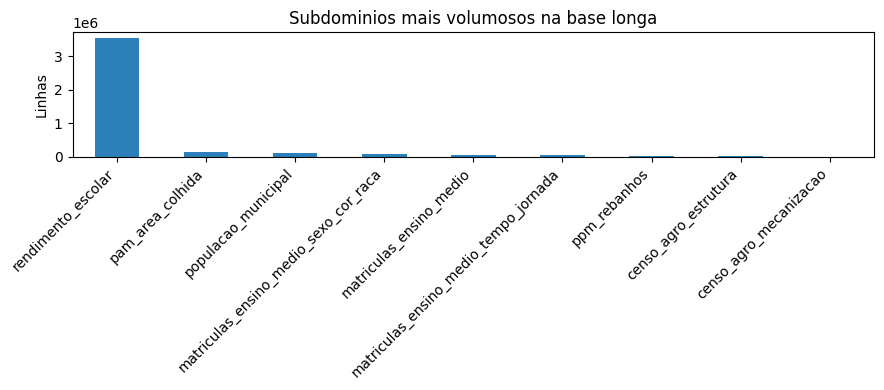

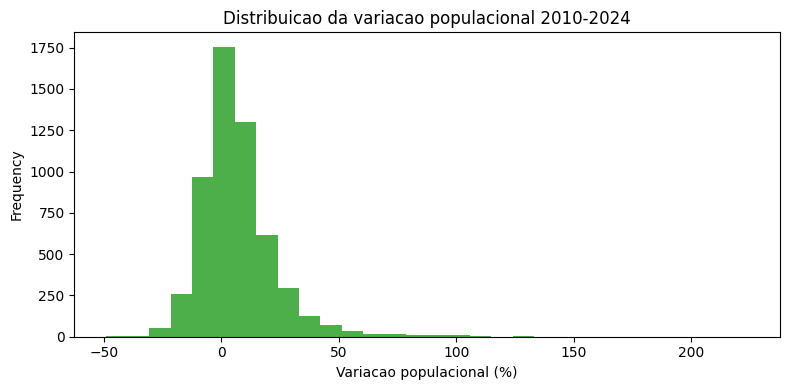

<Figure size 800x400 with 0 Axes>

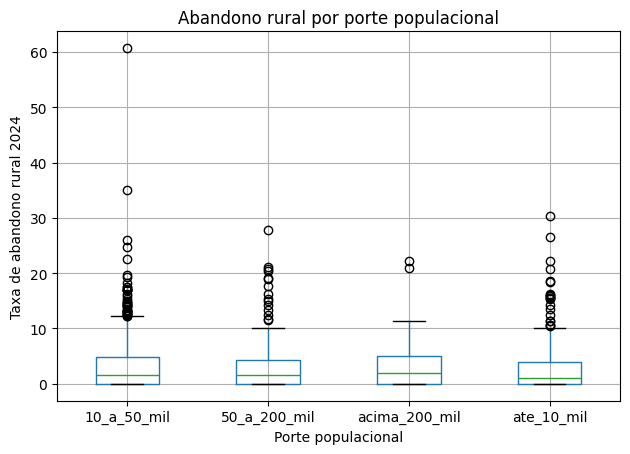

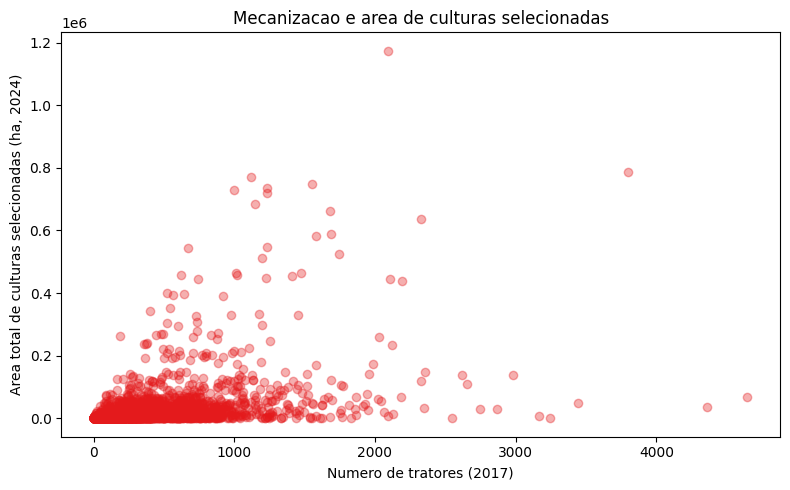

In [4]:

display(artifacts.painel_municipal.head(10))
display(artifacts.tabela_descritiva)
display(artifacts.comparacao_regiao)
display(artifacts.comparacao_porte)
display(artifacts.matriz_correlacao)
display(artifacts.destaques_area)
display(artifacts.destaques_bovinos)

serie_subdominios = artifacts.base_longa["subdominio"].value_counts().sort_values(ascending=False).head(10)
plotar_barras(serie_subdominios, "Subdominios mais volumosos na base longa", "Linhas")

plt.figure(figsize=(8, 4))
artifacts.painel_municipal["variacao_populacao_2010_2024_pct"].dropna().plot.hist(
    bins=30,
    color="#4daf4a",
    title="Distribuicao da variacao populacional 2010-2024",
)
plt.xlabel("Variacao populacional (%)")
plt.tight_layout()
plt.show()

boxplot_df = artifacts.painel_municipal.dropna(subset=["porte_populacional_2024", "taxa_abandono_rural_2024"]).copy()
plt.figure(figsize=(8, 4))
boxplot_df.boxplot(column="taxa_abandono_rural_2024", by="porte_populacional_2024")
plt.title("Abandono rural por porte populacional")
plt.suptitle("")
plt.xlabel("Porte populacional")
plt.ylabel("Taxa de abandono rural 2024")
plt.tight_layout()
plt.show()

scatter_df = artifacts.painel_municipal.dropna(subset=["num_tratores_2017", "area_total_culturas_selecionadas_hectares_2024"]).copy()
plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_df["num_tratores_2017"],
    scatter_df["area_total_culturas_selecionadas_hectares_2024"],
    alpha=0.35,
    color="#e41a1c",
)
plt.title("Mecanizacao e area de culturas selecionadas")
plt.xlabel("Numero de tratores (2017)")
plt.ylabel("Area total de culturas selecionadas (ha, 2024)")
plt.tight_layout()
plt.show()


In [5]:
display(Markdown(artifacts.conclusao_markdown))


## 3.4 Sintese interpretativa

Esta variante snapshot-free confirma que a **base longa** sustenta a leitura central do projeto sem exigir uma camada sintetica exportada.

- O arquivo canonico cobre **4,036,741 linhas**, **5,570 municipios** e **19 anos** entre **2006** e **2024**.
- Os **7 subdominios centrais** permanecem disponiveis na propria base longa, o que permite leituras descritivas por municipio, regiao, porte populacional e periodo.
- As agregacoes municipais mostradas neste volume sao **temporarias e analiticas**: elas servem para comparar padroes, nao para criar um novo artefato publico.
- O bloco educacional rural continua identificavel de forma explicita na base longa: **1,612 municipios** apresentam matriculas rurais positivas em 2024, e **1,612** contam com taxa de abandono observada no mesmo recorte.
- Em termos metodologicos, esta versao privilegia **rastreabilidade e auditabilidade**: toda a narrativa pode ser refeita a partir de `master_municipios_longo.csv`, sem depender de `regime_territorial` nem de exportacoes municipais sinteticas.



## 4. Dicionario e Validacao da Base Longa

O bloco seguinte descreve apenas o artefato canonico desta variante: `dados/saidas_finais/master_municipios_longo.csv`. O objetivo e documentar a estrutura do arquivo e verificar se o contrato de 21 colunas continua integro.


In [6]:

from __future__ import annotations

import warnings

import pandera.pandas as pa
from pandera import Check
from pandera.errors import SchemaErrors

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

df_long = artifacts.base_longa
LONG_PATH = artifacts.long_output_path

print(f"Base longa carregada em: {LONG_PATH}")
print(f"df_long: {df_long.shape[0]:,} linhas x {df_long.shape[1]} colunas")


Base longa carregada em: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_longo.csv
df_long: 4,036,741 linhas x 21 colunas



### 4.1 Visao geral e dicionario de dados

A visao geral abaixo resume o arquivo canonico, sua extensao temporal e o dominio observado em cada coluna.


In [7]:

def summarize_domain(series: pd.Series, max_categories: int = 8) -> str:
    non_null = series.dropna()
    if non_null.empty:
        return "sem valores observados"
    if pd.api.types.is_numeric_dtype(series):
        return f"{non_null.min()} a {non_null.max()}"
    unique_values = sorted(non_null.astype(str).unique().tolist())
    if len(unique_values) <= max_categories:
        return ", ".join(unique_values)
    return ", ".join(unique_values[:max_categories]) + f" ... (+{len(unique_values) - max_categories} valores)"


perfil_geral = pd.DataFrame(
    [
        {
            "artefato": "base_longa",
            "linhas": int(df_long.shape[0]),
            "colunas": int(df_long.shape[1]),
            "municipios": int(df_long["codigo_municipio"].nunique()),
        }
    ]
)
display(perfil_geral)

perfil_temporal = pd.DataFrame(
    [
        {
            "ano_min": int(df_long["ano_referencia"].min()),
            "ano_max": int(df_long["ano_referencia"].max()),
            "anos_distintos": int(df_long["ano_referencia"].nunique()),
        }
    ]
)
display(perfil_temporal)

perfil_long = pd.DataFrame(
    {
        "coluna": df_long.columns,
        "dtype": [str(df_long[coluna].dtype) for coluna in df_long.columns],
        "nulos": [int(df_long[coluna].isna().sum()) for coluna in df_long.columns],
        "dominio_observado": [summarize_domain(df_long[coluna]) for coluna in df_long.columns],
    }
)
display(perfil_long)

long_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave obrigatoria de integracao"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("ano_referencia", "int", "N", "2006 a 2024", "ano da observacao", "cada subdominio possui sua propria cobertura temporal"),
    ("fonte", "str", "N", "IBGE, INEP", "origem institucional da observacao", "mantem rastreabilidade da linha"),
    ("dominio", "str", "N", "demografia, agropecuaria, educacao", "macrodominio analitico", "usado para leituras comparativas"),
    ("subdominio", "str", "N", "subconjuntos oficiais por tema", "bloco substantivo dentro do dominio", "ex.: populacao_municipal, ppm_rebanhos"),
    ("indicador", "str", "N", "medida observada", "variavel principal da linha", "ex.: populacao_total, area_colhida"),
    ("categoria", "str", "N", "categoria tematica da observacao", "primeiro nivel de classificacao", "varia por fonte"),
    ("subcategoria", "str", "N", "subcategoria tematica", "segundo nivel de classificacao", "varia por fonte"),
    ("produto_codigo", "str", "S", "codigo oficial do produto ou variavel", "identificador tecnicamente associado a parte das fontes", "nulo quando nao se aplica"),
    ("produto_nome", "str", "S", "nome oficial do produto ou variavel", "rotulo substantivo complementar", "nulo quando nao se aplica"),
    ("localizacao", "str", "S", "Rural, Urbana, Total ou ausente", "recorte territorial interno", "preserva os filtros do bloco educacional"),
    ("dependencia_administrativa", "str", "S", "Total, Federal, Estadual, Municipal, Privada, Publica ou ausente", "segmentacao administrativa da observacao", "mais relevante nas tabelas educacionais"),
    ("etapa_ensino", "str", "S", "ensino_medio, ensino_fundamental ou ausente", "etapa educacional vinculada a linha", "nulo fora do dominio educacao"),
    ("serie", "str", "S", "total ou recorte especifico", "abertura complementar da observacao", "nulo quando nao se aplica"),
    ("unidade_medida", "str", "N", "habitantes, hectares, cabecas, matriculas, percentual, etc.", "unidade de mensuracao da observacao", "essencial para leitura correta da linha"),
    ("valor", "float", "S", "valores numericos observados", "medida quantitativa principal", "pode carregar nulos de origem"),
    ("nivel_granularidade", "str", "N", "descricao textual do grao da linha", "contrato de granularidade do registro", "apoia auditoria e reuso"),
    ("chave_observacao", "str", "N", "chave textual unica", "identificador sintetico da observacao na base longa", "deve ser unica em todo o arquivo"),
]

dicionario_long = pd.DataFrame(
    long_dictionary_rows,
    columns=["coluna", "tipo", "obrigatoria", "dominio", "papel", "observacao"],
)
display(dicionario_long)


,artefato,linhas,colunas,municipios
0,base_longa,4036741,21,5570


,ano_min,ano_max,anos_distintos
0,2006,2024,19


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,string,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,string,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,string,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,ano_referencia,int64,0,2006 a 2024
5,fonte,string,0,"IBGE, INEP"
6,dominio,string,0,"agropecuaria, demografia, educacao"
7,subdominio,string,0,"censo_agro_estrutura, censo_agro_mecanizacao, matriculas_ensino_medio, matriculas_ensino_medio_sexo_cor_raca, matriculas_ensino_medio_te..."
8,indicador,string,0,"area_colhida, area_estabelecimentos_agropecuarios, efetivo_rebanho, matriculas, numero_estabelecimentos_agropecuarios, numero_tratores, ..."
9,categoria,string,0,"estrutura_agropecuaria, lavoura_temporaria, matricula_escolar, mecanizacao, pecuaria, sexo_cor_raca, taxa_rendimento, tempo_jornada ... ..."


,coluna,tipo,obrigatoria,dominio,papel,observacao
0,codigo_municipio,int,N,codigo IBGE municipal com 7 digitos,identificador territorial padrao,chave obrigatoria de integracao
1,nome_municipio,str,N,nome oficial do municipio,rotulo textual municipal,nao deve ser usado como chave de merge
2,sigla_estado,str,N,UF brasileira em duas letras,sigla da unidade federativa,derivada do lookup territorial
3,regiao,str,N,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul",grande regiao geografica,derivada da UF
4,ano_referencia,int,N,2006 a 2024,ano da observacao,cada subdominio possui sua propria cobertura temporal
5,fonte,str,N,"IBGE, INEP",origem institucional da observacao,mantem rastreabilidade da linha
6,dominio,str,N,"demografia, agropecuaria, educacao",macrodominio analitico,usado para leituras comparativas
7,subdominio,str,N,subconjuntos oficiais por tema,bloco substantivo dentro do dominio,"ex.: populacao_municipal, ppm_rebanhos"
8,indicador,str,N,medida observada,variavel principal da linha,"ex.: populacao_total, area_colhida"
9,categoria,str,N,categoria tematica da observacao,primeiro nivel de classificacao,varia por fonte



### 4.2 Checagens de consistencia

As verificacoes abaixo se concentram no contrato da base longa: unicidade, cobertura minima dos subdominios centrais e integridade dos filtros educacionais rurais.


In [8]:

educacao_matriculas_rural = df_long.loc[
    (df_long["subdominio"].eq("matriculas_ensino_medio"))
    & (df_long["indicador"].eq("matriculas"))
    & (df_long["ano_referencia"].eq(2024))
    & (df_long["localizacao"].eq("Rural"))
    & (df_long["dependencia_administrativa"].eq("Total"))
    & (df_long["etapa_ensino"].eq("ensino_medio"))
    & (df_long["serie"].eq("total"))
].copy()

educacao_abandono_rural = df_long.loc[
    (df_long["subdominio"].eq("rendimento_escolar"))
    & (df_long["indicador"].eq("taxa_abandono"))
    & (df_long["ano_referencia"].eq(2024))
    & (df_long["localizacao"].eq("Rural"))
    & (df_long["dependencia_administrativa"].eq("Total"))
    & (df_long["etapa_ensino"].eq("ensino_medio"))
    & (df_long["serie"].eq("total"))
].copy()

checagens_integridade = pd.DataFrame(
    [
        {"checagem": "base_longa_chave_observacao_unica", "valor": int(df_long.duplicated(["chave_observacao"]).sum()) == 0},
        {"checagem": "base_longa_codigos_com_7_digitos", "valor": bool(df_long["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "base_longa_periodo_2006_2024", "valor": int(df_long["ano_referencia"].min()) == 2006 and int(df_long["ano_referencia"].max()) == 2024},
        {"checagem": "subdominios_centrais_presentes", "valor": set(SUBDOMINIOS_CENTRAIS).issubset(set(df_long["subdominio"].dropna().astype(str)))},
        {"checagem": "matriculas_rurais_total_ensino_medio_2024_presentes", "valor": not educacao_matriculas_rural.empty},
        {"checagem": "abandono_rural_total_ensino_medio_2024_presente", "valor": not educacao_abandono_rural.empty},
        {"checagem": "matriculas_rurais_sem_duplicidade_municipal", "valor": int(educacao_matriculas_rural.duplicated(["codigo_municipio"]).sum()) == 0},
        {"checagem": "abandono_rural_sem_duplicidade_municipal", "valor": int(educacao_abandono_rural.duplicated(["codigo_municipio"]).sum()) == 0},
        {"checagem": "nivel_granularidade_sem_nulos", "valor": bool(df_long["nivel_granularidade"].notna().all())},
    ]
)
display(checagens_integridade)

resumo_educacao_rural = pd.DataFrame(
    [
        {
            "recorte": "matriculas_rurais_ensino_medio_2024",
            "linhas": int(educacao_matriculas_rural.shape[0]),
            "municipios": int(educacao_matriculas_rural["codigo_municipio"].nunique()),
            "nulos_valor": int(educacao_matriculas_rural["valor"].isna().sum()),
        },
        {
            "recorte": "abandono_rural_ensino_medio_2024",
            "linhas": int(educacao_abandono_rural.shape[0]),
            "municipios": int(educacao_abandono_rural["codigo_municipio"].nunique()),
            "nulos_valor": int(educacao_abandono_rural["valor"].isna().sum()),
        },
    ]
)
display(resumo_educacao_rural)

display(educacao_matriculas_rural.head(10))
display(educacao_abandono_rural.head(10))


,checagem,valor
0,base_longa_chave_observacao_unica,True
1,base_longa_codigos_com_7_digitos,True
2,base_longa_periodo_2006_2024,True
3,subdominios_centrais_presentes,True
4,matriculas_rurais_total_ensino_medio_2024_presentes,True
5,abandono_rural_total_ensino_medio_2024_presente,True
6,matriculas_rurais_sem_duplicidade_municipal,True
7,abandono_rural_sem_duplicidade_municipal,True
8,nivel_granularidade_sem_nulos,True


,recorte,linhas,municipios,nulos_valor
0,matriculas_rurais_ensino_medio_2024,5570,5570,0
1,abandono_rural_ensino_medio_2024,4275,4275,2663


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
321995,1100015,Alta Floresta D'Oeste,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,72.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,15351569477240027465
321996,1100379,Alto Alegre dos Parecis,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,507037073389357042
321997,1100403,Alto Paraíso,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,7195061060442810400
321998,1100346,Alvorada D'Oeste,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,8256266842989629313
321999,1100023,Ariquemes,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,703.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,9228118931087467287
322000,1100452,Buritis,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,2073386320078421850
322001,1100031,Cabixi,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,33.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,17215320236840745746
322002,1100601,Cacaulândia,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,6654107186803093797
322003,1100049,Cacoal,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,189.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,5726885455363822276
322004,1100700,Campo Novo de Rondônia,RO,Norte,2024,INEP,educacao,matriculas_ensino_medio,matriculas,matricula_escolar,ensino_medio_regular,<NA>,<NA>,Rural,Total,ensino_medio,total,matriculas,92.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador,16380578626037166754


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
3643179,1100015,Alta Floresta D'Oeste,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,12900359096116179216
3643191,1100023,Ariquemes,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,1.6,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,12331159134463403130
3643207,1100031,Cabixi,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,1317830031833398319
3643218,1100049,Cacoal,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,0.6,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,791689937342799133
3643235,1100056,Cerejeiras,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,5900193154968992992
3643247,1100064,Colorado do Oeste,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,0.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,4882982393213130777
3643262,1100072,Corumbiara,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,1.0,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,7182188140873033666
3643274,1100080,Costa Marques,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,2.3,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,6600015274472961127
3643286,1100098,Espigão D'Oeste,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,2.6,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,16354868157424280900
3643300,1100106,Guajará-Mirim,RO,Norte,2024,INEP,educacao,rendimento_escolar,taxa_abandono,taxa_rendimento,ensino_basico,<NA>,<NA>,Rural,Total,ensino_medio,total,percentual,5.9,municipio_x_ano_x_localizacao_x_dependencia_x_indicador_x_etapa_x_serie,5207042832699067350



### 4.3 Validacao com pandera

A validacao formal abaixo confere se a base longa preserva o schema esperado de 21 colunas, sem recorrer a qualquer camada derivada de snapshot.


In [9]:

REGIOES_VALIDAS = ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"]
UFS_VALIDAS = sorted(df_long["sigla_estado"].dropna().astype(str).unique().tolist())

long_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "ano_referencia": pa.Column(int, checks=[Check.ge(2006), Check.le(2024)]),
        "fonte": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "dominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subdominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "indicador": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "categoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subcategoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "produto_codigo": pa.Column(str, nullable=True),
        "produto_nome": pa.Column(str, nullable=True),
        "localizacao": pa.Column(str, nullable=True),
        "dependencia_administrativa": pa.Column(str, nullable=True),
        "etapa_ensino": pa.Column(str, nullable=True),
        "serie": pa.Column(str, nullable=True),
        "unidade_medida": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "valor": pa.Column(float, nullable=True),
        "nivel_granularidade": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "chave_observacao": pa.Column(str, checks=[Check.str_length(min_value=1)]),
    },
    strict=True,
)

try:
    long_schema.validate(df_long, lazy=True)
    display(pd.DataFrame([{"schema": "base_longa", "status": "ok"}]))
except SchemaErrors as exc:
    display(exc.failure_cases.head(20))
    raise


,schema,status
0,base_longa,ok


In [10]:

total_municipios = int(df_long["codigo_municipio"].nunique())
subdominios_centrais = int(df_long[df_long["subdominio"].isin(SUBDOMINIOS_CENTRAIS)]["subdominio"].nunique())
municipios_matriculas = int(educacao_matriculas_rural["codigo_municipio"].nunique())
municipios_abandono = int(educacao_abandono_rural["codigo_municipio"].nunique())

resumo_final = f"""
## 4.4 Sintese da validacao

A validacao desta variante opera exclusivamente sobre `dados/saidas_finais/master_municipios_longo.csv`.

- A `base_longa` confirma o contrato de **{len(df_long.columns)} colunas** e preserva a unicidade por `chave_observacao`.
- O universo observado cobre **{total_municipios} municipios** ao longo de **{int(df_long['ano_referencia'].nunique())} anos**, de **{int(df_long['ano_referencia'].min())}** a **{int(df_long['ano_referencia'].max())}**.
- Os **{subdominios_centrais} subdominios centrais** definidos para o projeto estao presentes no arquivo canonico.
- O recorte educacional rural segue auditavel na propria base longa: **{municipios_matriculas} municipios** aparecem no recorte de matriculas rurais do ensino medio em 2024, e **{municipios_abandono}** no recorte de abandono rural correspondente.
- Nenhuma camada sintetica municipal e necessaria para reproduzir estas verificacoes. Toda a leitura apresentada neste notebook pode ser refeita diretamente a partir da base longa.
"""
display(Markdown(resumo_final))



## 4.4 Sintese da validacao

A validacao desta variante opera exclusivamente sobre `dados/saidas_finais/master_municipios_longo.csv`.

- A `base_longa` confirma o contrato de **21 colunas** e preserva a unicidade por `chave_observacao`.
- O universo observado cobre **5570 municipios** ao longo de **19 anos**, de **2006** a **2024**.
- Os **7 subdominios centrais** definidos para o projeto estao presentes no arquivo canonico.
- O recorte educacional rural segue auditavel na propria base longa: **5570 municipios** aparecem no recorte de matriculas rurais do ensino medio em 2024, e **4275** no recorte de abandono rural correspondente.
- Nenhuma camada sintetica municipal e necessaria para reproduzir estas verificacoes. Toda a leitura apresentada neste notebook pode ser refeita diretamente a partir da base longa.
